## 1. Dataset Loading and Initial Inspection

The first step is to load the datasets required for the hotel recommendation system and inspect their basic structure. The recommendation component is expected to use information about users, hotels, user preferences, and historical data. Therefore, before selecting a recommendation technique or performing any preprocessing, it is necessary to understand what information is actually available in the datasets.

In this step, the datasets are loaded into Pandas DataFrames and their dimensions, column names, data types, missing values, duplicate records, and sample observations are examined. This initial inspection will help determine the relationship between the user and hotel data and guide the preprocessing and recommendation approach used in the subsequent stages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()


Saving hotels.csv to hotels (4).csv
Saving users.csv to users (5).csv


In [3]:
users = pd.read_csv("users.csv")
hotels = pd.read_csv("hotels.csv")

print("Users dataset shape:", users.shape)
print("Hotels dataset shape:", hotels.shape)

print("\nUsers dataset:")
display(users.head())

print("\nHotels dataset:")
display(hotels.head())

Users dataset shape: (1340, 5)
Hotels dataset shape: (40552, 8)

Users dataset:


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44



Hotels dataset:


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [4]:
print("Users dataset information:")
users.info()

print("\nHotels dataset information:")
hotels.info()

Users dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB

Hotels dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: fl

In [5]:
print("Missing values in users.csv:")
display(users.isnull().sum())

print("\nMissing values in hotels.csv:")
display(hotels.isnull().sum())

print("Duplicate rows in users.csv:", users.duplicated().sum())
print("Duplicate rows in hotels.csv:", hotels.duplicated().sum())

Missing values in users.csv:


,0
code,0
company,0
name,0
gender,0
age,0



Missing values in hotels.csv:


,0
travelCode,0
userCode,0
name,0
place,0
days,0
price,0
total,0
date,0


Duplicate rows in users.csv: 0
Duplicate rows in hotels.csv: 0


## 2. Understanding the User–Hotel Relationship

The recommendation system needs to connect information about users with information about hotels. Before selecting a recommendation technique, it is important to determine how these two datasets are related and whether the available data contains direct evidence of user preferences or historical interactions with hotels.

In this step, the identifiers and potentially relevant attributes in both datasets are examined. We also investigate whether users and hotels can be connected through a common identifier or through historical interaction information such as bookings, ratings, reviews, or previous hotel selections.

The purpose of this analysis is to determine the type of recommendation problem supported by the available data. The findings will be used to select an appropriate recommendation strategy in the following stages.

In [6]:
print("Users dataset columns:")
print(users.columns.tolist())

print("\nHotels dataset columns:")
print(hotels.columns.tolist())

Users dataset columns:
['code', 'company', 'name', 'gender', 'age']

Hotels dataset columns:
['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']


In [7]:
print("Users dataset unique values:\n")

for column in users.columns:
    print(f"{column}: {users[column].nunique()} unique values")

print("\nHotels dataset unique values:\n")

for column in hotels.columns:
    print(f"{column}: {hotels[column].nunique()} unique values")

Users dataset unique values:

code: 1340 unique values
company: 5 unique values
name: 1338 unique values
gender: 3 unique values
age: 45 unique values

Hotels dataset unique values:

travelCode: 40552 unique values
userCode: 1310 unique values
name: 9 unique values
place: 9 unique values
days: 4 unique values
price: 9 unique values
total: 36 unique values
date: 199 unique values


In [8]:
user_id_candidates = [
    column for column in users.columns
    if "id" in column.lower()
]

hotel_id_candidates = [
    column for column in hotels.columns
    if "id" in column.lower()
]

print("Potential user ID columns:", user_id_candidates)
print("Potential hotel ID columns:", hotel_id_candidates)

Potential user ID columns: []
Potential hotel ID columns: []


In [9]:
categorical_user_columns = users.select_dtypes(
    include=["object", "category"]
).columns

categorical_hotel_columns = hotels.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns in users.csv:")
print(categorical_user_columns.tolist())

print("\nCategorical columns in hotels.csv:")
print(categorical_hotel_columns.tolist())

Categorical columns in users.csv:
['company', 'name', 'gender']

Categorical columns in hotels.csv:
['name', 'place', 'date']


In [10]:
print("Sample user records:")
display(users.sample(min(10, len(users)), random_state=42))

print("\nSample hotel records:")
display(hotels.sample(min(10, len(hotels)), random_state=42))

Sample user records:


,code,company,name,gender,age
394,394,4You,Tom Floyd,none,48
881,881,Wonka Company,Marlene Williams,female,42
358,358,4You,Rickey Orouke,male,46
367,367,4You,Deborah Adams,none,28
259,259,4You,Helen Walton,none,49
874,874,Wonka Company,Nancy Gentry,none,30
1203,1203,Umbrella LTDA,Troy Stenberg,none,53
1221,1221,Umbrella LTDA,Clifton Phillips,male,33
900,900,Acme Factory,Darin Lopez,male,35
710,710,Wonka Company,Cynthia Mekee,female,31



Sample hotel records:


,travelCode,userCode,name,place,days,price,total,date
216,767,6,Hotel AF,Sao Paulo (SP),3,139.10,417.30,04/01/2021
4199,13870,137,Hotel BW,Campo Grande (MS),4,60.39,241.56,03/18/2021
38515,129190,1272,Hotel CB,Rio de Janeiro (RJ),4,165.99,663.96,03/19/2020
38385,128800,1269,Hotel CB,Rio de Janeiro (RJ),1,165.99,165.99,11/04/2021
27080,91178,900,Hotel CB,Rio de Janeiro (RJ),4,165.99,663.96,11/07/2019
23293,78125,758,Hotel BD,Natal (RN),1,242.88,242.88,10/15/2020
31107,104553,1037,Hotel AF,Sao Paulo (SP),4,139.10,556.40,07/01/2021
5881,19393,189,Hotel CB,Rio de Janeiro (RJ),2,165.99,331.98,09/30/2021
18684,62281,607,Hotel BD,Natal (RN),3,242.88,728.64,05/06/2021
17237,57370,558,Hotel A,Florianopolis (SC),3,313.02,939.06,06/24/2021


In [11]:
common_columns = sorted(
    set(users.columns).intersection(set(hotels.columns))
)

print("Columns shared by both datasets:")
print(common_columns)

Columns shared by both datasets:
['name']


In [12]:
print("Numerical columns in users.csv:")
display(users.describe(include="all").T)

print("\nNumerical columns in hotels.csv:")
display(hotels.describe(include="all").T)

Numerical columns in users.csv:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,1340.0,NaN,NaN,NaN,669.5,386.968991,0.0,334.75,669.5,1004.25,1339.0
company,1340,5,4You,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,1340,1338,Charlotte Johnson,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1340,3,male,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1340.0,NaN,NaN,NaN,42.742537,12.869779,21.0,32.0,42.0,54.0,65.0



Numerical columns in hotels.csv:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
travelCode,40552.0,NaN,NaN,NaN,67911.794461,39408.199333,0.0,33696.75,67831.0,102211.25,135942.0
userCode,40552.0,NaN,NaN,NaN,666.963726,391.136794,0.0,323.0,658.0,1013.0,1339.0
name,40552,9,Hotel K,5094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
place,40552,9,Salvador (BH),5094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days,40552.0,NaN,NaN,NaN,2.499679,1.119326,1.0,1.0,2.0,4.0,4.0
price,40552.0,NaN,NaN,NaN,214.439554,76.742305,60.39,165.99,242.88,263.41,313.02
total,40552.0,NaN,NaN,NaN,536.229513,319.331482,60.39,247.62,495.24,742.86,1252.08
date,40552,199,10/03/2019,404,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning and Preprocessing

The datasets are cleaned and prepared before building the hotel recommendation system. The cleaning process focuses on identifying and handling duplicate records, missing values, inconsistent text representations, and inappropriate data types while preserving the information required for recommendation.

Separate copies of the original user and hotel datasets are created so that the raw data remains unchanged. Missing values are examined before deciding how they should be handled, since the appropriate treatment depends on the meaning and distribution of each attribute. Text-based categorical attributes are standardized where appropriate, while numerical attributes are converted to suitable numeric representations when necessary.

The cleaned datasets will be used for exploratory analysis, feature engineering, and development of the recommendation model.

In [13]:
users_clean = users.copy()
hotels_clean = hotels.copy()

print("Users working copy shape:", users_clean.shape)
print("Hotels working copy shape:", hotels_clean.shape)

Users working copy shape: (1340, 5)
Hotels working copy shape: (40552, 8)


In [14]:
users_clean = users_clean.dropna(axis=0, how="all")
users_clean = users_clean.dropna(axis=1, how="all")

hotels_clean = hotels_clean.dropna(axis=0, how="all")
hotels_clean = hotels_clean.dropna(axis=1, how="all")

print("Users shape after removing completely empty rows/columns:", users_clean.shape)
print("Hotels shape after removing completely empty rows/columns:", hotels_clean.shape)

Users shape after removing completely empty rows/columns: (1340, 5)
Hotels shape after removing completely empty rows/columns: (40552, 8)


In [15]:
users_duplicates = users_clean.duplicated().sum()
hotels_duplicates = hotels_clean.duplicated().sum()

print("Duplicate user records:", users_duplicates)
print("Duplicate hotel records:", hotels_duplicates)

users_clean = users_clean.drop_duplicates().reset_index(drop=True)
hotels_clean = hotels_clean.drop_duplicates().reset_index(drop=True)

print("\nUsers shape after duplicate removal:", users_clean.shape)
print("Hotels shape after duplicate removal:", hotels_clean.shape)

Duplicate user records: 0
Duplicate hotel records: 0

Users shape after duplicate removal: (1340, 5)
Hotels shape after duplicate removal: (40552, 8)


In [16]:
users_clean.columns = (
    users_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

hotels_clean.columns = (
    hotels_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

print("Cleaned user columns:")
print(users_clean.columns.tolist())

print("\nCleaned hotel columns:")
print(hotels_clean.columns.tolist())

Cleaned user columns:
['code', 'company', 'name', 'gender', 'age']

Cleaned hotel columns:
['travelcode', 'usercode', 'name', 'place', 'days', 'price', 'total', 'date']


In [17]:
for column in users_clean.select_dtypes(include=["object"]).columns:
    users_clean[column] = users_clean[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

for column in hotels_clean.select_dtypes(include=["object"]).columns:
    hotels_clean[column] = hotels_clean[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Whitespace cleaning completed.")

Whitespace cleaning completed.


In [18]:
users_missing = users_clean.isnull().sum()
hotels_missing = hotels_clean.isnull().sum()

print("Missing values in users dataset:")
display(users_missing[users_missing > 0].sort_values(ascending=False))

print("\nMissing values in hotels dataset:")
display(hotels_missing[hotels_missing > 0].sort_values(ascending=False))

Missing values in users dataset:


,0



Missing values in hotels dataset:


,0


In [19]:
users_missing_pct = (
    users_clean.isnull().mean() * 100
).sort_values(ascending=False)

hotels_missing_pct = (
    hotels_clean.isnull().mean() * 100
).sort_values(ascending=False)

print("Users dataset missing-value percentages:")
display(users_missing_pct[users_missing_pct > 0])

print("\nHotels dataset missing-value percentages:")
display(hotels_missing_pct[hotels_missing_pct > 0])

Users dataset missing-value percentages:


,0



Hotels dataset missing-value percentages:


,0


In [20]:
users_numeric = users_clean.select_dtypes(include=np.number)
hotels_numeric = hotels_clean.select_dtypes(include=np.number)

users_infinite = np.isinf(users_numeric).sum().sum()
hotels_infinite = np.isinf(hotels_numeric).sum().sum()

print("Infinite numerical values in users dataset:", users_infinite)
print("Infinite numerical values in hotels dataset:", hotels_infinite)

Infinite numerical values in users dataset: 0
Infinite numerical values in hotels dataset: 0


In [21]:
print("FINAL USERS DATASET")
print("=" * 40)
print("Rows:", users_clean.shape[0])
print("Columns:", users_clean.shape[1])
print("Duplicate rows:", users_clean.duplicated().sum())
print("Missing values:", users_clean.isnull().sum().sum())

print("\nFINAL HOTELS DATASET")
print("=" * 40)
print("Rows:", hotels_clean.shape[0])
print("Columns:", hotels_clean.shape[1])
print("Duplicate rows:", hotels_clean.duplicated().sum())
print("Missing values:", hotels_clean.isnull().sum().sum())

FINAL USERS DATASET
Rows: 1340
Columns: 5
Duplicate rows: 0
Missing values: 0

FINAL HOTELS DATASET
Rows: 40552
Columns: 8
Duplicate rows: 0
Missing values: 0


## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the characteristics and distributions of the cleaned user and hotel datasets. The analysis examines numerical and categorical attributes, user demographics or preferences, hotel characteristics, and the availability and distribution of potentially important recommendation features.

For numerical attributes, descriptive statistics and distributions are examined to identify typical values, variability, and potential outliers. For categorical attributes, the most frequent categories and their distributions are analyzed. The hotel dataset is also examined for characteristics such as price, rating, location, and other available attributes that may influence recommendations.

The purpose of this analysis is to identify meaningful patterns and determine which attributes can be used during feature engineering and recommendation model development.

In [22]:
print("Users dataset")
print("=" * 50)
print(users_clean.shape)
display(users_clean.head())

print("\nHotels dataset")
print("=" * 50)
print(hotels_clean.shape)
display(hotels_clean.head())

Users dataset
(1340, 5)


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44



Hotels dataset
(40552, 8)


,travelcode,usercode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [23]:
user_numeric_columns = users_clean.select_dtypes(
    include=np.number
).columns.tolist()

hotel_numeric_columns = hotels_clean.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns in users dataset:")
print(user_numeric_columns)

print("\nNumerical columns in hotels dataset:")
print(hotel_numeric_columns)

Numerical columns in users dataset:
['code', 'age']

Numerical columns in hotels dataset:
['travelcode', 'usercode', 'days', 'price', 'total']


In [24]:
if user_numeric_columns:
    display(users_clean[user_numeric_columns].describe().T)
else:
    print("No numerical columns found in the users dataset.")

,count,mean,std,min,25%,50%,75%,max
code,1340.0,669.500000,386.968991,0.0,334.75,669.5,1004.25,1339.0
age,1340.0,42.742537,12.869779,21.0,32.00,42.0,54.00,65.0


In [25]:
if hotel_numeric_columns:
    display(hotels_clean[hotel_numeric_columns].describe().T)
else:
    print("No numerical columns found in the hotels dataset.")

,count,mean,std,min,25%,50%,75%,max
travelcode,40552.0,67911.794461,39408.199333,0.00,33696.75,67831.00,102211.25,135942.00
usercode,40552.0,666.963726,391.136794,0.00,323.00,658.00,1013.00,1339.00
days,40552.0,2.499679,1.119326,1.00,1.00,2.00,4.00,4.00
price,40552.0,214.439554,76.742305,60.39,165.99,242.88,263.41,313.02
total,40552.0,536.229513,319.331482,60.39,247.62,495.24,742.86,1252.08


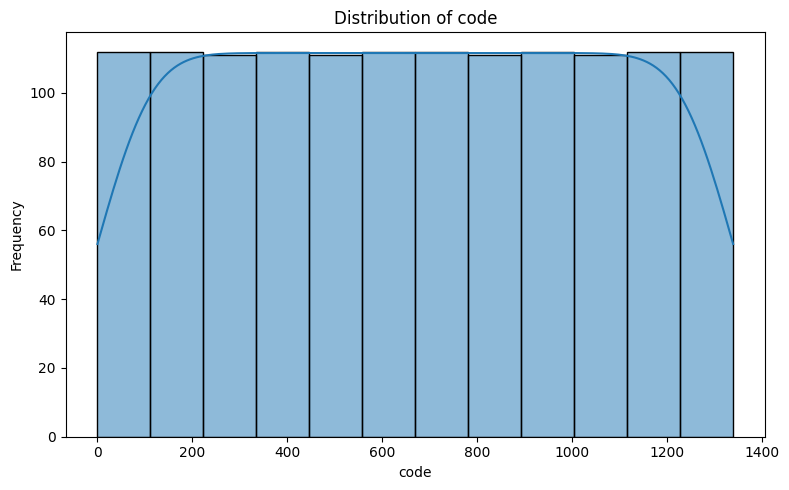

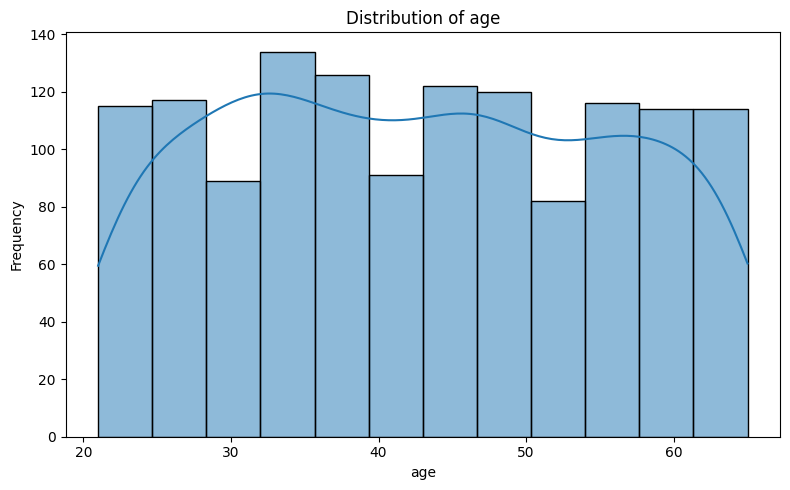

In [26]:
for column in user_numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(users_clean[column].dropna(), kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

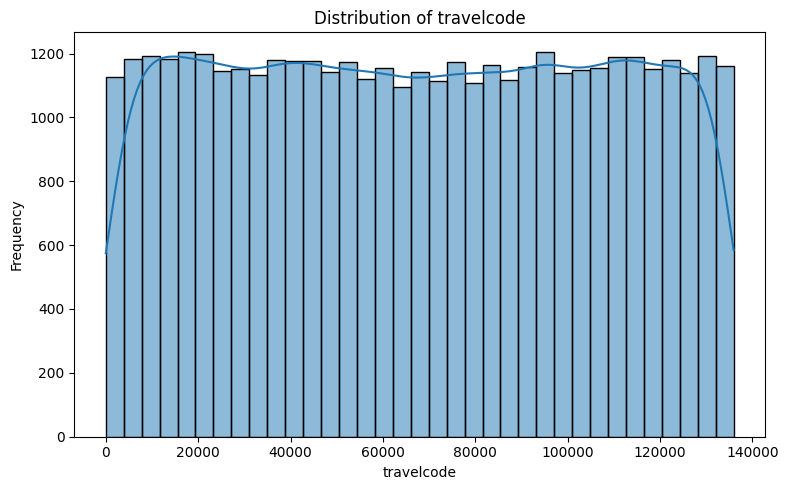

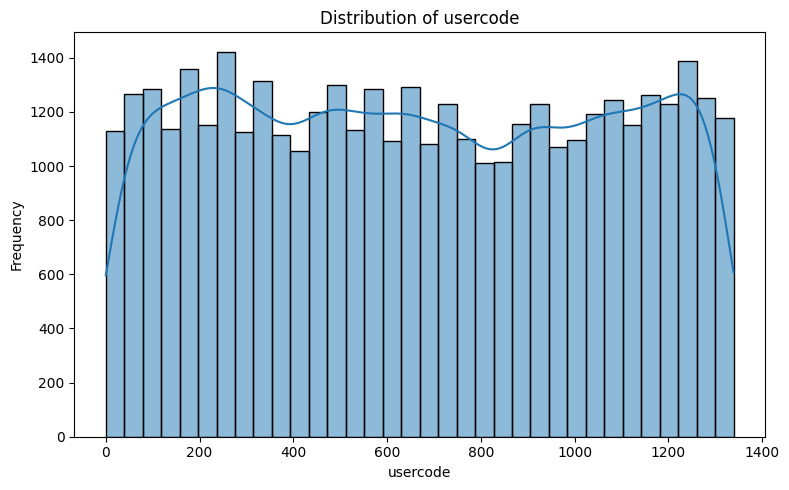

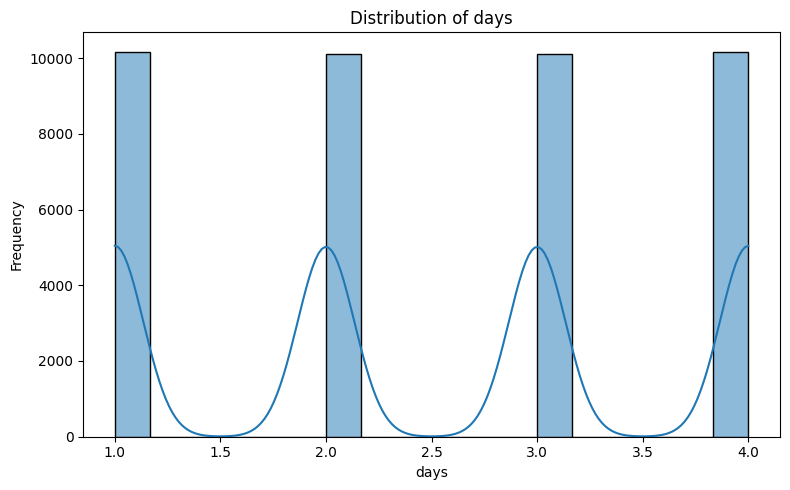

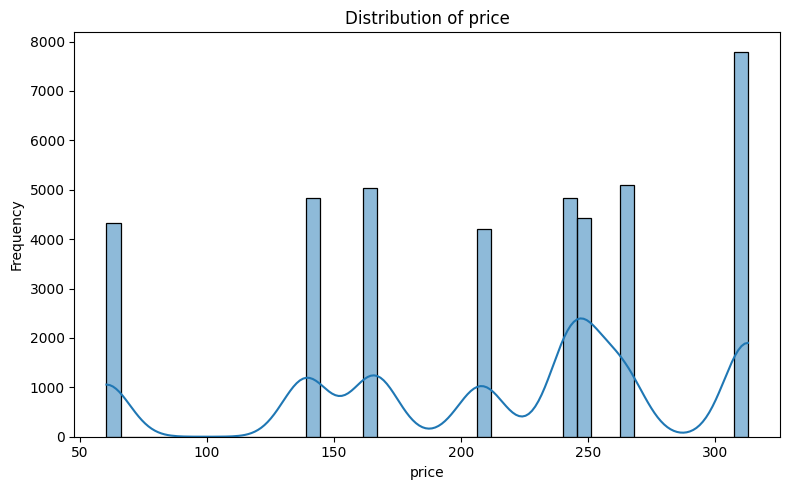

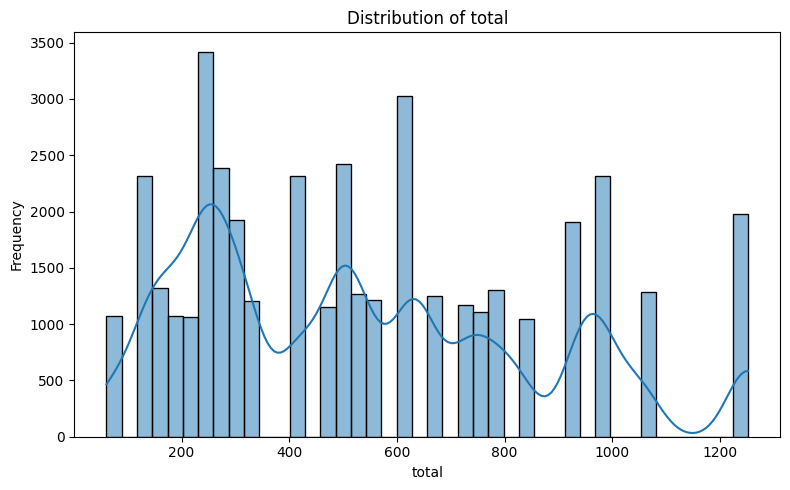

In [27]:
for column in hotel_numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(hotels_clean[column].dropna(), kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [28]:
user_categorical_columns = users_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

hotel_categorical_columns = hotels_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns in users dataset:")
print(user_categorical_columns)

print("\nCategorical columns in hotels dataset:")
print(hotel_categorical_columns)

Categorical columns in users dataset:
['company', 'name', 'gender']

Categorical columns in hotels dataset:
['name', 'place', 'date']


In [29]:
for column in user_categorical_columns:
    value_counts = users_clean[column].value_counts(dropna=False).head(15)

    print(f"\n{column}")
    display(value_counts)


company


,count
company,
4You,453
Acme Factory,261
Wonka Company,237
Monsters CYA,195
Umbrella LTDA,194



name


,count
name,
Charlotte Johnson,2
David Robinson,2
Patricia Hardy,1
Edwin Miller,1
Thomas Smith,1
Josephine Sigmon,1
Alex Fratta,1
Ashley Miller,1
Jessica Godina,1



gender


,count
gender,
male,452
female,448
none,440


In [30]:
for column in hotel_categorical_columns:
    value_counts = hotels_clean[column].value_counts(dropna=False).head(15)

    print(f"\n{column}")
    display(value_counts)


name


,count
name,
Hotel K,5094
Hotel CB,5029
Hotel BD,4829
Hotel AF,4828
Hotel AU,4467
Hotel BP,4437
Hotel BW,4333
Hotel Z,4205
Hotel A,3330



place


,count
place,
Salvador (BH),5094
Rio de Janeiro (RJ),5029
Natal (RN),4829
Sao Paulo (SP),4828
Recife (PE),4467
Brasilia (DF),4437
Campo Grande (MS),4333
Aracaju (SE),4205
Florianopolis (SC),3330



date


,count
date,
10/03/2019,404
10/31/2019,404
10/24/2019,401
02/13/2020,390
10/17/2019,390
10/10/2019,389
09/26/2019,386
12/19/2019,383
11/07/2019,380


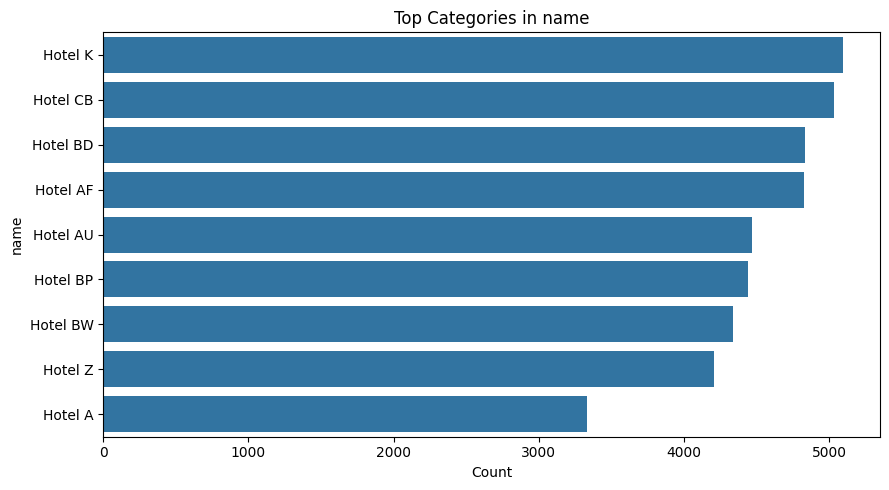

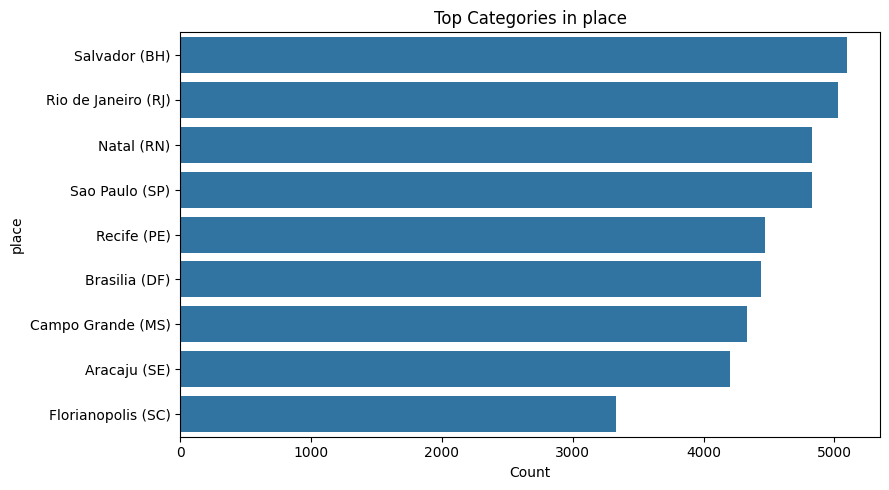

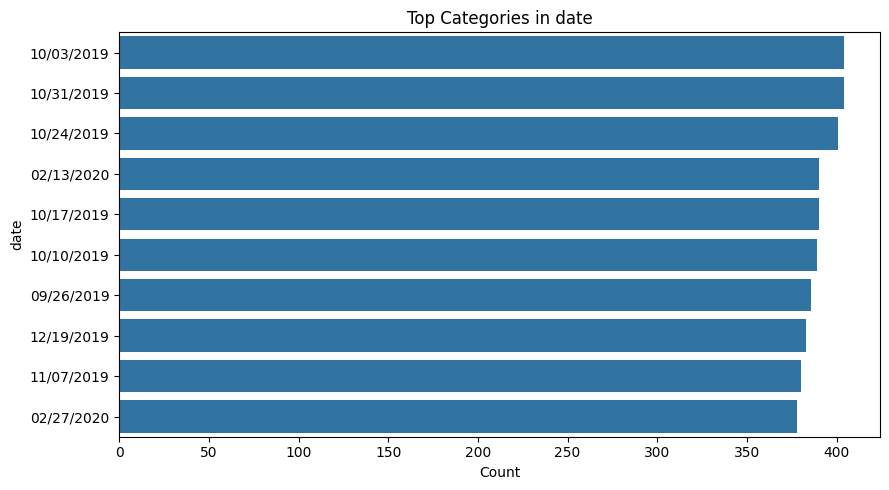

In [31]:
for column in hotel_categorical_columns:
    value_counts = hotels_clean[column].value_counts().head(10)

    if len(value_counts) > 0:
        plt.figure(figsize=(9, 5))
        sns.barplot(
            x=value_counts.values,
            y=value_counts.index
        )
        plt.title(f"Top Categories in {column}")
        plt.xlabel("Count")
        plt.ylabel(column)
        plt.tight_layout()
        plt.show()

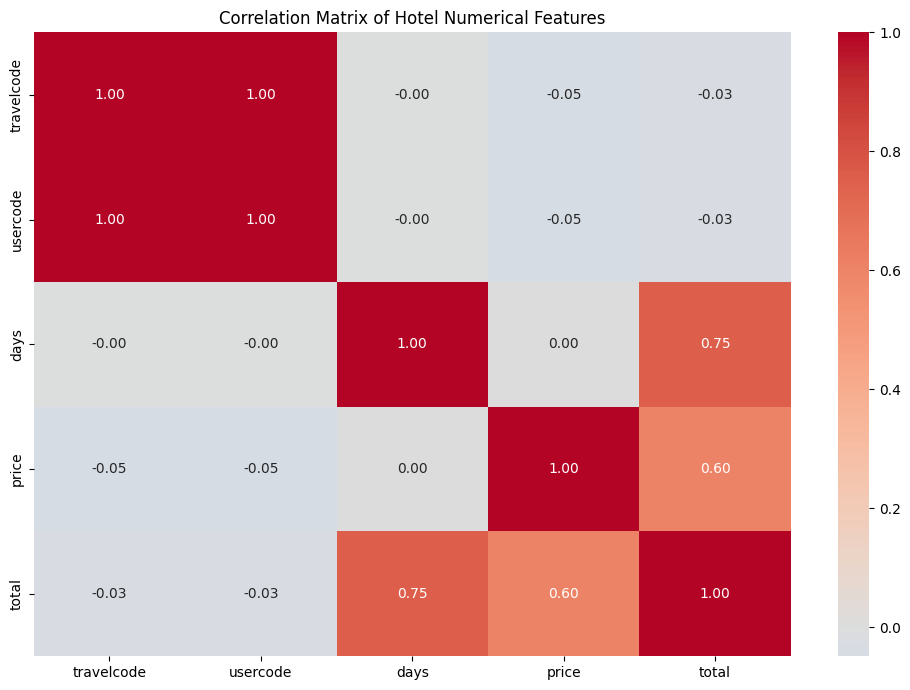

In [32]:
if len(hotel_numeric_columns) >= 2:
    plt.figure(figsize=(10, 7))

    correlation_matrix = hotels_clean[
        hotel_numeric_columns
    ].corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title("Correlation Matrix of Hotel Numerical Features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical hotel features for correlation analysis.")

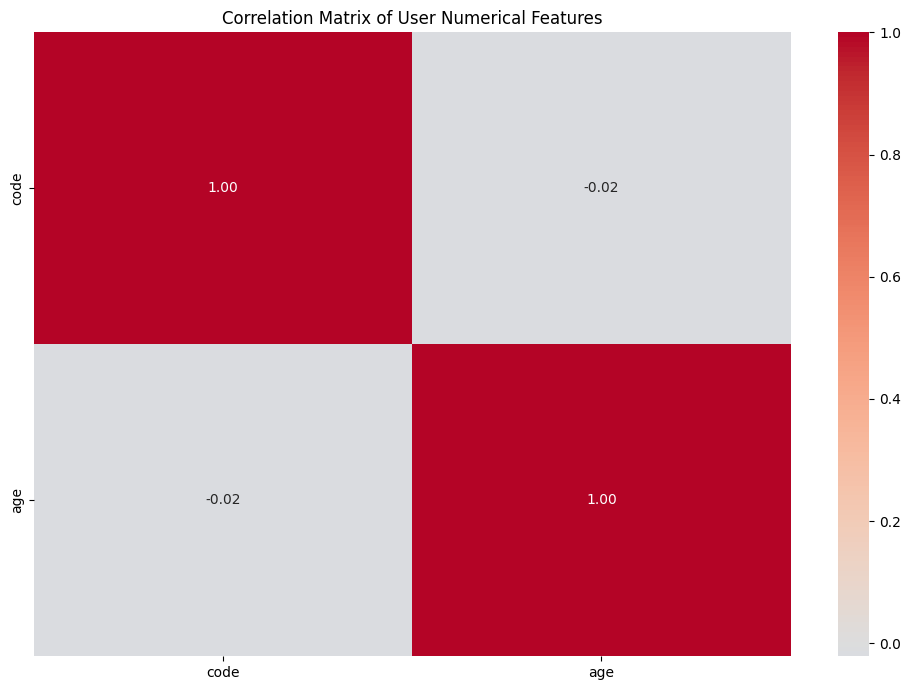

In [33]:
if len(user_numeric_columns) >= 2:
    plt.figure(figsize=(10, 7))

    correlation_matrix = users_clean[
        user_numeric_columns
    ].corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title("Correlation Matrix of User Numerical Features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical user features for correlation analysis.")

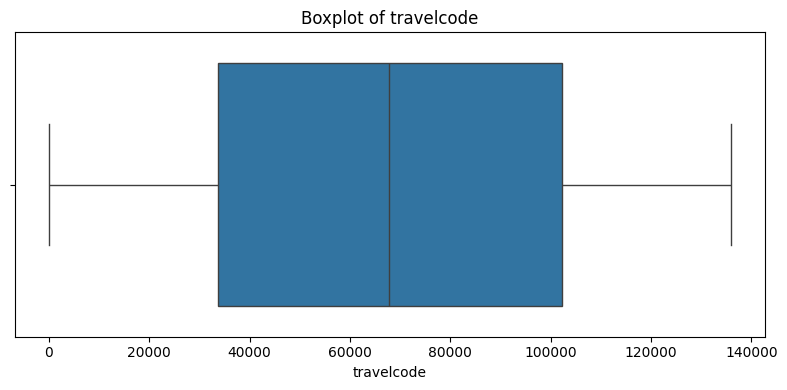

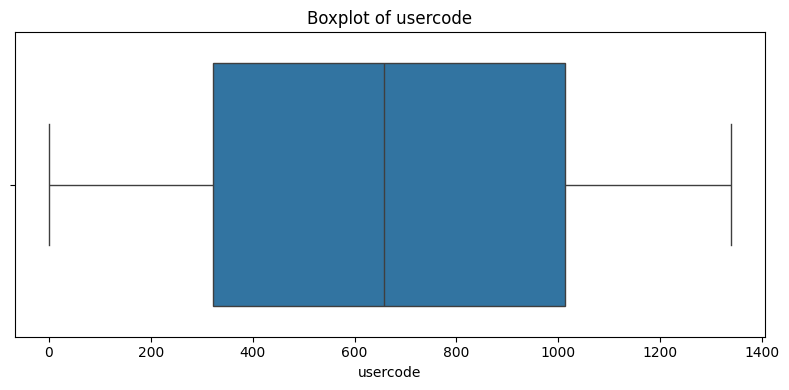

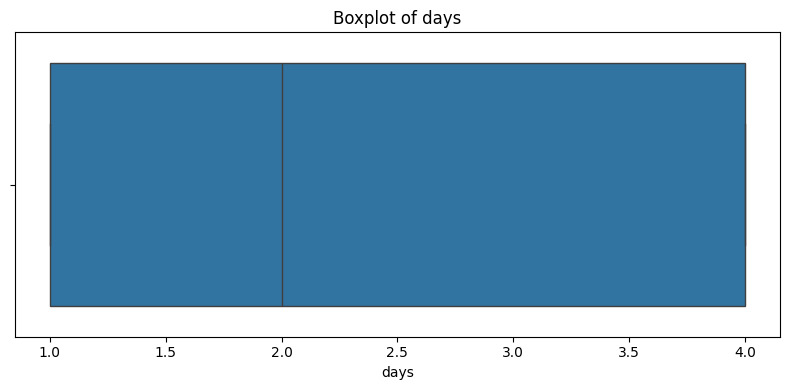

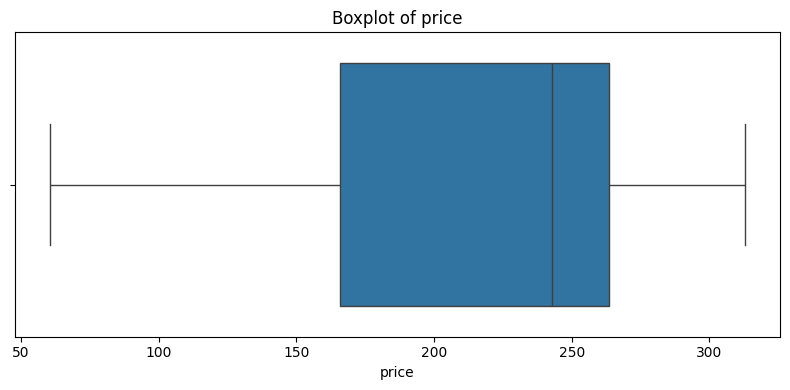

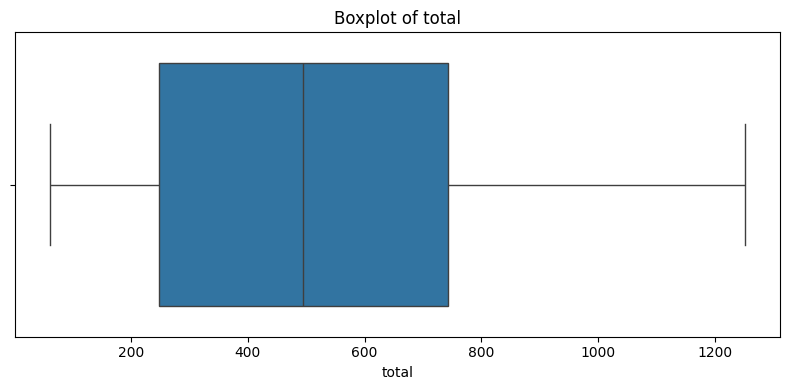

In [34]:
for column in hotel_numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=hotels_clean[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [35]:
print("Potential user features:")
for column in users_clean.columns:
    print(f"- {column}")

print("\nPotential hotel features:")
for column in hotels_clean.columns:
    print(f"- {column}")

Potential user features:
- code
- company
- name
- gender
- age

Potential hotel features:
- travelcode
- usercode
- name
- place
- days
- price
- total
- date


## 5. Feature Engineering and Recommendation Strategy

Feature engineering prepares the cleaned hotel data for use by the recommendation system. The objective is to transform the available hotel attributes into a numerical representation that can be compared between hotels.

Identifier columns are excluded from the feature representation because they identify individual records rather than describe hotel characteristics. The remaining numerical and categorical attributes are separated according to their data types.

Numerical features are processed by replacing missing values with their median values and standardizing their scales. Categorical features are processed by replacing missing values with an "Unknown" category and applying one-hot encoding. The resulting numerical and categorical representations are then combined into a single hotel feature matrix.

At this stage, the feature representation is prepared but no recommendation algorithm is trained. The resulting feature matrix will be inspected before proceeding to the recommendation model.

In [36]:
print("Users cleaned dataset:", users_clean.shape)
print("Hotels cleaned dataset:", hotels_clean.shape)

display(users_clean.head())
display(hotels_clean.head())

Users cleaned dataset: (1340, 5)
Hotels cleaned dataset: (40552, 8)


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


,travelcode,usercode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [37]:
user_id_columns = [
    column for column in users_clean.columns
    if "id" in column.lower()
]

hotel_id_columns = [
    column for column in hotels_clean.columns
    if "id" in column.lower()
]

print("Potential user identifier columns:")
print(user_id_columns)

print("\nPotential hotel identifier columns:")
print(hotel_id_columns)

Potential user identifier columns:
[]

Potential hotel identifier columns:
[]


In [38]:
hotel_feature_columns = [
    column for column in hotels_clean.columns
    if column not in hotel_id_columns
]

hotel_features = hotels_clean[
    hotel_feature_columns
].copy()

print("Hotel feature columns:")
print(hotel_feature_columns)

print("\nHotel feature dataset shape:")
print(hotel_features.shape)

display(hotel_features.head())

Hotel feature columns:
['travelcode', 'usercode', 'name', 'place', 'days', 'price', 'total', 'date']

Hotel feature dataset shape:
(40552, 8)


,travelcode,usercode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [39]:
hotel_numeric_features = hotel_features.select_dtypes(
    include=np.number
).columns.tolist()

hotel_categorical_features = hotel_features.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical hotel features:")
print(hotel_numeric_features)

print("\nCategorical hotel features:")
print(hotel_categorical_features)

Numerical hotel features:
['travelcode', 'usercode', 'days', 'price', 'total']

Categorical hotel features:
['name', 'place', 'date']


### Numerical Feature Processing

Numerical hotel attributes may have different scales. For example, a price feature may contain values in hundreds while a rating feature may range between 1 and 5. Using these values directly could cause larger-scale variables to dominate similarity calculations.

Missing numerical values are therefore replaced using the median of the corresponding feature, and the resulting features are standardized using StandardScaler. This produces numerical features with comparable scales for subsequent similarity calculations.

In [40]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

if len(hotel_numeric_features) > 0:
    hotel_numeric_imputer = SimpleImputer(
        strategy="median"
    )

    hotel_numeric_matrix = hotel_numeric_imputer.fit_transform(
        hotel_features[hotel_numeric_features]
    )

    hotel_numeric_scaler = StandardScaler()

    hotel_numeric_matrix = hotel_numeric_scaler.fit_transform(
        hotel_numeric_matrix
    )

    print(
        "Numerical feature matrix shape:",
        hotel_numeric_matrix.shape
    )
else:
    hotel_numeric_imputer = None
    hotel_numeric_scaler = None

    hotel_numeric_matrix = np.empty(
        (len(hotel_features), 0)
    )

    print("No numerical hotel features were found.")

Numerical feature matrix shape: (40552, 5)


### Categorical Feature Processing

Categorical hotel attributes cannot be directly used in numerical similarity calculations. They are therefore converted into numerical representations using one-hot encoding.

Each distinct category is represented by a binary feature. The encoder is configured with handle_unknown="ignore" so that categories not observed during model construction do not cause errors when the recommendation system is later used with new data.

In [41]:
from sklearn.preprocessing import OneHotEncoder

if len(hotel_categorical_features) > 0:
    hotel_categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    hotel_categorical_matrix = (
        hotel_categorical_encoder.fit_transform(
            hotel_features[
                hotel_categorical_features
            ].fillna("Unknown")
        )
    )

    print(
        "Categorical feature matrix shape:",
        hotel_categorical_matrix.shape
    )
else:
    hotel_categorical_encoder = None

    hotel_categorical_matrix = np.empty(
        (len(hotel_features), 0)
    )

    print("No categorical hotel features were found.")

Categorical feature matrix shape: (40552, 217)


### Combined Hotel Feature Representation

The processed numerical and categorical feature representations are combined into a single feature matrix. Each row represents one hotel, while each column represents a processed hotel characteristic.

This combined representation forms the input to the recommendation system. At this stage, the matrix contains only hotel characteristics and does not yet contain user-specific information.

In [42]:
hotel_feature_matrix = np.hstack(
    [
        hotel_numeric_matrix,
        hotel_categorical_matrix
    ]
)

print("Hotel feature matrix shape:")
print(hotel_feature_matrix.shape)

print(
    "\nNumber of hotels:",
    hotel_feature_matrix.shape[0]
)
hotel_feature_matrix = np.hstack(
    [
        hotel_numeric_matrix,
        hotel_categorical_matrix
    ]
)

print("Hotel feature matrix shape:")
print(hotel_feature_matrix.shape)

print(
    "\nNumber of hotels:",
    hotel_feature_matrix.shape[0]
)

print(
    "Number of features:",
    hotel_feature_matrix.shape[1]
)
print(
    "Number of features:",
    hotel_feature_matrix.shape[1]
)

Hotel feature matrix shape:
(40552, 222)

Number of hotels: 40552
Hotel feature matrix shape:
(40552, 222)

Number of hotels: 40552
Number of features: 222
Number of features: 222


In [43]:
print("Feature matrix data type:")
print(hotel_feature_matrix.dtype)

print("\nContains NaN values:")
print(np.isnan(hotel_feature_matrix).any())

print("\nContains infinite values:")
print(np.isinf(hotel_feature_matrix).any())

print("\nFeature matrix minimum:")
print(hotel_feature_matrix.min())

print("\nFeature matrix maximum:")
print(hotel_feature_matrix.max())

Feature matrix data type:
float64

Contains NaN values:
False

Contains infinite values:
False

Feature matrix minimum:
-2.0073863198539694

Feature matrix maximum:
2.241743620680132


In [44]:
feature_preview = pd.DataFrame(
    hotel_feature_matrix
)

display(
    feature_preview.head()
)

print(
    "Processed feature matrix memory usage:",
    hotel_feature_matrix.nbytes / (1024 ** 2),
    "MB"
)

,0,1,2,3,4,5,6,7,8,9,...,212,213,214,215,216,217,218,219,220,221
0,-1.723312,-1.705214,1.340395,1.284580,2.241744,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.723261,-1.705214,-0.446416,0.638123,-0.029467,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.723135,-1.705214,0.446989,0.638123,0.795423,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.723033,-1.705214,1.340395,0.638123,1.620313,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.722982,-1.705214,-1.339822,1.284580,-0.698999,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Processed feature matrix memory usage: 68.6839599609375 MB


### Recommendation Strategy Selection

The recommendation strategy is determined from the information available in the datasets. A content-based approach can be used when hotel attributes and user preferences are available but explicit user–hotel interaction history is limited. A collaborative filtering approach requires explicit interactions between users and hotels, such as ratings, bookings, or previous selections. If both types of information are available, a hybrid approach may be considered.

The recommendation strategy is therefore selected only after examining the available user and hotel attributes and their relationships.

In [45]:
interaction_keywords = [
    "rating",
    "review",
    "booking",
    "reservation",
    "interaction",
    "visit",
    "stay",
    "hotel_id"
]

possible_user_interaction_columns = [
    column
    for column in users_clean.columns
    if any(
        keyword in column.lower()
        for keyword in interaction_keywords
    )
]

possible_hotel_interaction_columns = [
    column
    for column in hotels_clean.columns
    if any(
        keyword in column.lower()
        for keyword in interaction_keywords
    )
]

print("Possible interaction columns in users dataset:")
print(possible_user_interaction_columns)

print(
    "\nPossible interaction columns in hotels dataset:"
)
print(possible_hotel_interaction_columns)

Possible interaction columns in users dataset:
[]

Possible interaction columns in hotels dataset:
[]


## 6. Building the Hotel Recommendation Model

Since the available datasets do not contain explicit user–hotel interaction records, a collaborative filtering approach is not applicable. A content-based recommendation approach is therefore used.

The recommendation system represents hotels according to their available characteristics, including numerical and categorical attributes prepared during feature engineering. Similarity between hotels is calculated using cosine similarity.

The system ranks hotels according to their similarity in the feature space and uses these rankings as the basis for personalized hotel recommendations. User-specific preferences will subsequently be matched with the corresponding hotel characteristics so that recommendations can be tailored to individual users.

This approach is suitable for the available data because it does not require historical user–hotel ratings or booking interactions. Instead, recommendations are generated from the characteristics of the hotels and the preferences available for each user.

In [47]:
print("Users dataset columns:")
print(users_clean.columns.tolist())

print("\nHotels dataset columns:")
print(hotels_clean.columns.tolist())

Users dataset columns:
['code', 'company', 'name', 'gender', 'age']

Hotels dataset columns:
['travelcode', 'usercode', 'name', 'place', 'days', 'price', 'total', 'date']


In [48]:
print("Users dataset shape:", users_clean.shape)
print("Hotels dataset shape:", hotels_clean.shape)

print("\nSample users:")
display(users_clean.head())

print("\nSample hotels:")
display(hotels_clean.head())

Users dataset shape: (1340, 5)
Hotels dataset shape: (40552, 8)

Sample users:


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44



Sample hotels:


,travelcode,usercode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


## Understanding Historical User–Hotel Interactions

The hotel dataset contains historical travel records in which each record is associated with a user through the `usercode` attribute. These records provide implicit user–hotel interaction information because a hotel appearing in a user's historical records indicates that the user previously selected or stayed at that hotel.

Although explicit hotel ratings are not available, the historical records can be used to infer user preferences from repeated hotel selections, destinations, prices, and stay durations.

This historical interaction information is used to personalize hotel recommendations. The recommendation system will identify hotels that are similar to the hotels previously selected by a user and rank candidate hotels according to their similarity to the user's historical preferences.

In [49]:
print("Users columns:")
print(users_clean.columns.tolist())

print("\nHotel/travel columns:")
print(hotels_clean.columns.tolist())

Users columns:
['code', 'company', 'name', 'gender', 'age']

Hotel/travel columns:
['travelcode', 'usercode', 'name', 'place', 'days', 'price', 'total', 'date']


In [50]:
print("\nNumber of users:", users_clean["code"].nunique())
print("Number of historical records:", len(hotels_clean))
print("Number of users with historical records:", hotels_clean["usercode"].nunique())
print("Number of unique hotels:", hotels_clean["name"].nunique())
print("Number of unique places:", hotels_clean["place"].nunique())


Number of users: 1340
Number of historical records: 40552
Number of users with historical records: 1310
Number of unique hotels: 9
Number of unique places: 9


## User Historical Travel Profile

The historical records are grouped by `usercode` to determine the travel behaviour of individual users. The number of historical records provides an indication of how much information is available for each user.

Users with multiple historical records provide sufficient information for identifying repeated destinations, hotels, and spending patterns. This historical behaviour will later be used to generate personalized recommendations.

In [51]:
user_history = (
    hotels_clean
    .groupby("usercode")
    .agg(
        total_trips=("travelcode", "count"),
        unique_hotels=("name", "nunique"),
        unique_places=("place", "nunique"),
        average_price=("price", "mean"),
        average_days=("days", "mean"),
        total_spending=("total", "sum")
    )
    .reset_index()
)

display(user_history.head())

,usercode,total_trips,unique_hotels,unique_places,average_price,average_days,total_spending
0,0,27,9,9,225.741481,2.629630,16014.92
1,1,2,2,2,193.360000,1.000000,386.72
2,2,36,9,9,210.050000,2.694444,20088.12
3,3,60,9,9,217.058500,2.300000,29974.11
4,4,56,9,9,214.947679,2.571429,31657.70


In [52]:
test_user = hotels_clean["usercode"].iloc[0]

print("Selected user:", test_user)

user_travel_history = hotels_clean[
    hotels_clean["usercode"] == test_user
].sort_values("date")

display(user_travel_history)

Selected user: 0


,travelcode,usercode,name,place,days,price,total,date
5,15,0,Hotel BD,Natal (RN),2,242.88,485.76,01/09/2020
23,73,0,Hotel BP,Brasilia (DF),4,247.62,990.48,02/18/2021
6,22,0,Hotel Z,Aracaju (SE),2,208.04,416.08,02/27/2020
24,81,0,Hotel BD,Natal (RN),4,242.88,971.52,04/15/2021
7,29,0,Hotel AU,Recife (PE),4,312.83,1251.32,04/16/2020
8,32,0,Hotel AF,Sao Paulo (SP),2,139.10,278.20,05/07/2020
9,33,0,Hotel K,Salvador (BH),4,263.41,1053.64,05/14/2020
25,86,0,Hotel AF,Sao Paulo (SP),3,139.10,417.30,05/20/2021
10,34,0,Hotel AF,Sao Paulo (SP),3,139.10,417.30,05/21/2020
26,87,0,Hotel AU,Recife (PE),1,312.83,312.83,05/27/2021


## Historical Destination Preferences

Destination preference is inferred from the places that appear most frequently in a user's historical travel records. The frequency of previous visits provides an implicit indication of the user's destination preferences.

These preferences will be used when ranking candidate hotels.

In [53]:
user_place_preferences = (
    hotels_clean
    .groupby(["usercode", "place"])
    .size()
    .reset_index(name="visit_count")
)

user_place_preferences = user_place_preferences.sort_values(
    ["usercode", "visit_count"],
    ascending=[True, False]
)

display(user_place_preferences.head(20))

,usercode,place,visit_count
7,0,Salvador (BH),7
4,0,Natal (RN),4
8,0,Sao Paulo (SP),4
0,0,Aracaju (SE),3
3,0,Florianopolis (SC),3
2,0,Campo Grande (MS),2
5,0,Recife (PE),2
1,0,Brasilia (DF),1
6,0,Rio de Janeiro (RJ),1
9,1,Brasilia (DF),1


In [54]:
user_hotel_preferences = (
    hotels_clean
    .groupby(["usercode", "name"])
    .agg(
        visit_count=("travelcode", "count"),
        average_price=("price", "mean"),
        average_days=("days", "mean")
    )
    .reset_index()
)

user_hotel_preferences = user_hotel_preferences.sort_values(
    ["usercode", "visit_count"],
    ascending=[True, False]
)

display(user_hotel_preferences.head(20))

,usercode,name,visit_count,average_price,average_days
7,0,Hotel K,7,263.41,2.714286
1,0,Hotel AF,4,139.10,2.750000
3,0,Hotel BD,4,242.88,2.250000
0,0,Hotel A,3,313.02,2.333333
8,0,Hotel Z,3,208.04,3.333333
2,0,Hotel AU,2,312.83,2.500000
5,0,Hotel BW,2,60.39,2.500000
4,0,Hotel BP,1,247.62,4.000000
6,0,Hotel CB,1,165.99,1.000000
9,1,Hotel AF,1,139.10,1.000000


## Hotel Feature Representation

The hotel records contain attributes describing the selected accommodation and the associated travel characteristics. The `usercode` and `travelcode` attributes are identifiers and are therefore excluded from the hotel feature representation.

The hotel name and destination are represented as categorical features, while price and stay duration are represented as numerical features. These features provide a representation of the characteristics associated with historical hotel selections.

The resulting feature representation is used to compare candidate hotels with the historical preferences of individual users.

In [55]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [56]:
hotel_model_features = hotels_clean[
    ["name", "place", "price", "days"]
].copy()

print(hotel_model_features.head())

      name               place   price  days
0  Hotel A  Florianopolis (SC)  313.02     4
1  Hotel K       Salvador (BH)  263.41     2
2  Hotel K       Salvador (BH)  263.41     3
3  Hotel K       Salvador (BH)  263.41     4
4  Hotel A  Florianopolis (SC)  313.02     1


In [57]:
hotel_catalog = (
    hotels_clean[
        ["name", "place", "price"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Historical records:", len(hotels_clean))
print("Unique hotel profiles:", len(hotel_catalog))

display(hotel_catalog.head())

Historical records: 40552
Unique hotel profiles: 9


,name,place,price
0,Hotel A,Florianopolis (SC),313.02
1,Hotel K,Salvador (BH),263.41
2,Hotel BD,Natal (RN),242.88
3,Hotel Z,Aracaju (SE),208.04
4,Hotel AU,Recife (PE),312.83


In [59]:
categorical_features = [
    "name",
    "place"
]

numerical_features = [
    "price"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            numerical_features
        )
    ]
)

In [60]:
hotel_feature_matrix = preprocessor.fit_transform(
    hotel_catalog
)

print(
    "Hotel feature matrix shape:",
    hotel_feature_matrix.shape
)

Hotel feature matrix shape: (9, 19)


In [61]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

recommendation_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

recommendation_model.fit(
    hotel_feature_matrix
)

print("Recommendation model trained successfully.")

Recommendation model trained successfully.


In [69]:
def recommend_similar_hotels(hotel_name, top_n=5):
    matching_indices = hotel_catalog.index[
        hotel_catalog["name"] == hotel_name
    ].tolist()

    if not matching_indices:
        raise ValueError(
            f"Hotel '{hotel_name}' was not found."
        )

    hotel_index = matching_indices[0]

    total_hotels = len(hotel_catalog)

    # +1 because the selected hotel itself is included
    n_neighbors = min(
        top_n + 1,
        total_hotels
    )

    distances, indices = recommendation_model.kneighbors(
        hotel_feature_matrix[hotel_index],
        n_neighbors=n_neighbors
    )

    result_indices = indices[0][1:]
    result_distances = distances[0][1:]

    recommendations = hotel_catalog.iloc[
        result_indices
    ].copy()

    recommendations["similarity_score"] = (
        1 - result_distances
    )

    return recommendations.reset_index(drop=True)


def recommend_for_user(user_code, top_n=5):

    user_history = hotels_clean[
        hotels_clean["usercode"] == user_code
    ]

    if user_history.empty:
        raise ValueError(
            f"No historical data found for user {user_code}."
        )

    previous_hotels = (
        user_history["name"]
        .dropna()
        .unique()
        .tolist()
    )

    candidate_scores = {}

    for hotel_name in previous_hotels:

        if hotel_name not in set(
            hotel_catalog["name"]
        ):
            continue

        # Never request more neighbours than actually exist
        available_alternatives = max(
            0,
            len(hotel_catalog) - 1
        )

        if available_alternatives == 0:
            continue

        n_to_search = min(
            top_n * 3,
            available_alternatives
        )

        similar_hotels = recommend_similar_hotels(
            hotel_name,
            top_n=n_to_search
        )

        for _, row in similar_hotels.iterrows():

            candidate = row["name"]
            score = row["similarity_score"]

            # Do not recommend something the user already visited
            if candidate in previous_hotels:
                continue

            candidate_scores[candidate] = (
                candidate_scores.get(candidate, 0)
                + score
            )

    if not candidate_scores:
        return pd.DataFrame(
            columns=[
                "name",
                "recommendation_score",
                "place",
                "price"
            ]
        )

    recommendations = pd.DataFrame(
        candidate_scores.items(),
        columns=[
            "name",
            "recommendation_score"
        ]
    )

    recommendations = recommendations.sort_values(
        "recommendation_score",
        ascending=False
    )

    recommendations = recommendations.head(top_n)

    recommendations = recommendations.merge(
        hotel_catalog,
        on="name",
        how="left"
    )

    return recommendations.reset_index(drop=True)

In [70]:
test_hotel = hotel_catalog["name"].iloc[0]

print("Selected hotel:")
print(test_hotel)

print("\nRecommended hotels:")

display(
    recommend_similar_hotels(
        test_hotel,
        top_n=5
    )
)

Selected hotel:
Hotel A

Recommended hotels:


,name,place,price,similarity_score
0,Hotel AU,Recife (PE),312.83,0.427385
1,Hotel K,Salvador (BH),263.41,0.252186
2,Hotel BP,Brasilia (DF),247.62,0.173785
3,Hotel BD,Natal (RN),242.88,0.148360
4,Hotel Z,Aracaju (SE),208.04,-0.052812


## Personalized User Recommendation

The personalized recommendation function uses the user's historical hotel selections as implicit preference information.

For each hotel previously selected by the user, similar hotels are identified from the hotel catalogue. The candidate recommendations are then aggregated across the user's historical selections. Hotels that repeatedly appear as similar candidates receive stronger recommendation scores.

Hotels that the user has already visited are excluded from the final recommendation list so that the system focuses on potentially new accommodation options.

In [71]:
def recommend_for_user(
    user_code,
    top_n=5
):
    user_history = hotels_clean[
        hotels_clean["usercode"] == user_code
    ]

    if user_history.empty:
        raise ValueError(
            f"No historical data found for user {user_code}."
        )

    previous_hotels = (
        user_history["name"]
        .dropna()
        .unique()
        .tolist()
    )

    candidate_scores = {}

    for hotel_name in previous_hotels:

        if hotel_name not in set(
            hotel_catalog["name"]
        ):
            continue

        available_alternatives = max(
            1,
            len(hotel_catalog) - 1
        )

        similar_hotels = recommend_similar_hotels(
            hotel_name,
            top_n=min(
                top_n * 3,
                available_alternatives
            )
        )

        for _, row in similar_hotels.iterrows():

            candidate = row["name"]
            score = row["similarity_score"]

            if candidate in previous_hotels:
                continue

            candidate_scores[candidate] = (
                candidate_scores.get(
                    candidate,
                    0
                ) + score
            )

    if not candidate_scores:
        return pd.DataFrame(
            columns=[
                "name",
                "recommendation_score",
                "place",
                "price"
            ]
        )

    recommendations = pd.DataFrame(
        candidate_scores.items(),
        columns=[
            "name",
            "recommendation_score"
        ]
    )

    recommendations = recommendations.sort_values(
        "recommendation_score",
        ascending=False
    )

    recommendations = recommendations.head(
        top_n
    )

    recommendations = recommendations.merge(
        hotel_catalog,
        on="name",
        how="left"
    )

    return recommendations.reset_index(
        drop=True
    )

In [72]:
test_user = hotels_clean["usercode"].iloc[0]

print("User:", test_user)

print("\nHistorical hotels:")

display(
    hotels_clean[
        hotels_clean["usercode"] == test_user
    ][
        [
            "name",
            "place",
            "price",
            "days",
            "date"
        ]
    ]
)

print("\nRecommended hotels:")

display(
    recommend_for_user(
        test_user,
        top_n=5
    )
)

User: 0

Historical hotels:


,name,place,price,days,date
0,Hotel A,Florianopolis (SC),313.02,4,09/26/2019
1,Hotel K,Salvador (BH),263.41,2,10/10/2019
2,Hotel K,Salvador (BH),263.41,3,11/14/2019
3,Hotel K,Salvador (BH),263.41,4,12/12/2019
4,Hotel A,Florianopolis (SC),313.02,1,12/26/2019
5,Hotel BD,Natal (RN),242.88,2,01/09/2020
6,Hotel Z,Aracaju (SE),208.04,2,02/27/2020
7,Hotel AU,Recife (PE),312.83,4,04/16/2020
8,Hotel AF,Sao Paulo (SP),139.10,2,05/07/2020
9,Hotel K,Salvador (BH),263.41,4,05/14/2020



Recommended hotels:


,name,recommendation_score,place,price


### Selecting a Test User

The recommendation system is evaluated using users who have historical hotel interactions but have not interacted with every hotel in the available catalogue.

Users who have already visited all available hotels cannot receive a new-hotel recommendation under the current recommendation setting. Therefore, a suitable test user is selected based on the number of unique hotels present in their historical records.

In [77]:
user_hotel_counts = (
    hotels_clean
    .groupby("usercode")["name"]
    .nunique()
    .sort_values()
)

print("Users with the fewest unique hotel interactions:")
display(user_hotel_counts.head(20))

Users with the fewest unique hotel interactions:


,name
usercode,
1338,1
1292,1
473,1
1275,1
530,1
592,1
377,1
819,1
270,1


In [78]:
candidate_users = user_hotel_counts[
    user_hotel_counts < hotels_clean["name"].nunique()
]

print(
    "Number of users with unseen hotels available:",
    len(candidate_users)
)

display(candidate_users.head(10))

Number of users with unseen hotels available: 934


,name
usercode,
1338,1
1292,1
473,1
1275,1
530,1
592,1
377,1
819,1
270,1


In [79]:
test_user = candidate_users.index[0]

print("Selected test user:", test_user)

print(
    "Unique hotels visited:",
    candidate_users.loc[test_user]
)

print(
    "Hotels available for recommendation:",
    hotels_clean["name"].nunique()
    - candidate_users.loc[test_user]
)

Selected test user: 1338
Unique hotels visited: 1
Hotels available for recommendation: 8


In [80]:
print("Historical hotels for user", test_user)

display(
    hotels_clean[
        hotels_clean["usercode"] == test_user
    ][
        [
            "name",
            "place",
            "price",
            "days",
            "date"
        ]
    ].sort_values("date")
)

print("\nRecommended hotels:")

user_recommendations = recommend_for_user(
    test_user,
    top_n=5
)

display(user_recommendations)

Historical hotels for user 1338


,name,place,price,days,date
40538,Hotel BP,Brasilia (DF),247.62,4,10/03/2019



Recommended hotels:


,name,recommendation_score,place,price
0,Hotel A,0.173785,Florianopolis (SC),313.02
1,Hotel AU,0.173588,Recife (PE),312.83
2,Hotel K,0.102428,Salvador (BH),263.41
3,Hotel BD,0.060258,Natal (RN),242.88
4,Hotel Z,-0.021450,Aracaju (SE),208.04


## 7. Recommendation Evaluation Strategy

The recommendation system is evaluated using historical user–hotel interactions. A temporal evaluation strategy is used to simulate a realistic recommendation scenario.

For each user, the historical interactions are ordered chronologically. Earlier interactions are used as the user's known history, while a later interaction is treated as the target item that the system should ideally recommend.

The recommendation quality is measured using Precision@K, Recall@K, and Hit Rate@K. These metrics evaluate whether hotels that users interacted with later were successfully included among the top-ranked recommendations.

In [81]:
evaluation_data = hotels_clean.copy()

evaluation_data["date"] = pd.to_datetime(
    evaluation_data["date"]
)

evaluation_data = evaluation_data.sort_values(
    ["usercode", "date"]
).reset_index(drop=True)

print("Evaluation dataset shape:")
print(evaluation_data.shape)

print("\nDate range:")
print(
    evaluation_data["date"].min(),
    "to",
    evaluation_data["date"].max()
)

Evaluation dataset shape:
(40552, 8)

Date range:
2019-09-26 00:00:00 to 2023-07-13 00:00:00


## Temporal Train/Test Split

A leave-one-last-interaction-out strategy is used for evaluation. For users with at least two historical interactions, the final chronological interaction is held out as the test interaction, while all preceding interactions form the user's historical profile.

This simulates the practical recommendation scenario in which the system uses a user's previous behaviour to recommend a hotel for a future trip.

Users with only one interaction are excluded from this evaluation because there is no earlier interaction available for constructing a user profile.

In [82]:
user_interaction_counts = (
    evaluation_data
    .groupby("usercode")
    .size()
)

eligible_users = user_interaction_counts[
    user_interaction_counts >= 2
].index

print(
    "Total users:",
    evaluation_data["usercode"].nunique()
)

print(
    "Users with at least 2 interactions:",
    len(eligible_users)
)

Total users: 1310
Users with at least 2 interactions: 1288


In [83]:
train_interactions = []
test_interactions = []

for user_code in eligible_users:

    user_data = evaluation_data[
        evaluation_data["usercode"] == user_code
    ].sort_values("date")

    train_interactions.append(
        user_data.iloc[:-1]
    )

    test_interactions.append(
        user_data.iloc[-1:]
    )

train_interactions = pd.concat(
    train_interactions
).reset_index(drop=True)

test_interactions = pd.concat(
    test_interactions
).reset_index(drop=True)

print("Training interactions:")
print(train_interactions.shape)

print("\nTest interactions:")
print(test_interactions.shape)

Training interactions:
(39242, 8)

Test interactions:
(1288, 8)


In [84]:
display(
    test_interactions[
        [
            "usercode",
            "name",
            "place",
            "price",
            "date"
        ]
    ].head(10)
)

,usercode,name,place,price,date
0,0,Hotel AU,Recife (PE),312.83,2021-05-27
1,1,Hotel BP,Brasilia (DF),247.62,2019-10-17
2,2,Hotel BD,Natal (RN),242.88,2022-03-24
3,3,Hotel CB,Rio de Janeiro (RJ),165.99,2023-07-13
4,4,Hotel BD,Natal (RN),242.88,2023-07-13
5,5,Hotel Z,Aracaju (SE),208.04,2020-12-10
6,6,Hotel AF,Sao Paulo (SP),139.10,2021-04-01
7,7,Hotel BW,Campo Grande (MS),60.39,2020-09-03
8,8,Hotel K,Salvador (BH),263.41,2022-12-01
9,9,Hotel BW,Campo Grande (MS),60.39,2021-10-28


## Training-Only Recommendation Function

To prevent data leakage, recommendations during evaluation are generated exclusively from the user's historical training interactions.

The held-out test interaction is not provided to the recommendation function. This ensures that the evaluation measures the model's ability to recommend a future hotel based only on information that would have been available at recommendation time.

In [85]:
def recommend_for_user_from_history(
    user_history,
    top_n=5
):

    previous_hotels = (
        user_history["name"]
        .dropna()
        .unique()
        .tolist()
    )

    candidate_scores = {}

    for hotel_name in previous_hotels:

        if hotel_name not in set(
            hotel_catalog["name"]
        ):
            continue

        available_alternatives = max(
            0,
            len(hotel_catalog) - 1
        )

        if available_alternatives == 0:
            continue

        n_to_search = min(
            top_n * 3,
            available_alternatives
        )

        similar_hotels = recommend_similar_hotels(
            hotel_name,
            top_n=n_to_search
        )

        for _, row in similar_hotels.iterrows():

            candidate = row["name"]
            score = row["similarity_score"]

            if candidate in previous_hotels:
                continue

            candidate_scores[candidate] = (
                candidate_scores.get(
                    candidate,
                    0
                ) + score
            )

    if not candidate_scores:
        return []

    ranked_candidates = sorted(
        candidate_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        hotel_name
        for hotel_name, score
        in ranked_candidates[:top_n]
    ]

In [86]:
evaluation_user = train_interactions[
    "usercode"
].iloc[0]

user_history = train_interactions[
    train_interactions["usercode"]
    == evaluation_user
]

actual_test_hotel = test_interactions[
    test_interactions["usercode"]
    == evaluation_user
]["name"].iloc[0]

recommendations = (
    recommend_for_user_from_history(
        user_history,
        top_n=5
    )
)

print("User:", evaluation_user)

print("\nTraining history:")
display(
    user_history[
        [
            "name",
            "place",
            "price",
            "date"
        ]
    ]
)

print("\nActual future hotel:")
print(actual_test_hotel)

print("\nRecommended hotels:")
print(recommendations)

User: 0

Training history:


,name,place,price,date
0,Hotel A,Florianopolis (SC),313.02,2019-09-26
1,Hotel K,Salvador (BH),263.41,2019-10-10
2,Hotel K,Salvador (BH),263.41,2019-11-14
3,Hotel K,Salvador (BH),263.41,2019-12-12
4,Hotel A,Florianopolis (SC),313.02,2019-12-26
5,Hotel BD,Natal (RN),242.88,2020-01-09
6,Hotel Z,Aracaju (SE),208.04,2020-02-27
7,Hotel AU,Recife (PE),312.83,2020-04-16
8,Hotel AF,Sao Paulo (SP),139.10,2020-05-07
9,Hotel K,Salvador (BH),263.41,2020-05-14



Actual future hotel:
Hotel AU

Recommended hotels:
[]


## Hit Rate@K

Hit Rate@K measures whether the actual future hotel interaction appears anywhere in the top K recommendations.

A hit is recorded when the held-out hotel is included in the recommendation list. Otherwise, the prediction is considered a miss.

Hit Rate@K is calculated as:

Hit Rate@K = Number of users with a successful recommendation / Total number of evaluated users

In [87]:
def hit_rate_at_k(
    actual_items,
    recommended_items,
    k
):
    return int(
        actual_items in recommended_items[:k]
    )

## Precision@K

Precision@K measures the proportion of the top K recommendations that correspond to relevant items.

Because the evaluation uses one held-out future hotel for each user, the maximum number of relevant items is one.

Precision@K is calculated as:

Precision@K = Relevant recommended items / K

In [88]:
def precision_at_k(
    actual_item,
    recommended_items,
    k
):

    recommended_top_k = recommended_items[:k]

    if actual_item in recommended_top_k:
        return 1 / k

    return 0.0

## Recall@K

Recall@K measures whether the relevant future hotel was successfully retrieved within the top K recommendations.

Since the evaluation contains one held-out relevant hotel per user, Recall@K is equivalent to a binary hit indicator:

Recall@K = 1 if the relevant hotel appears in the Top-K list, otherwise 0.

In [89]:
def recall_at_k(
    actual_item,
    recommended_items,
    k
):

    if actual_item in recommended_items[:k]:
        return 1.0

    return 0.0

In [90]:
k_values = [1, 3, 5]

results = []

for user_code in eligible_users:

    user_history = train_interactions[
        train_interactions["usercode"]
        == user_code
    ]

    user_test = test_interactions[
        test_interactions["usercode"]
        == user_code
    ]

    if user_test.empty:
        continue

    actual_hotel = user_test[
        "name"
    ].iloc[0]

    recommendations = (
        recommend_for_user_from_history(
            user_history,
            top_n=max(k_values)
        )
    )

    for k in k_values:

        results.append({
            "usercode": user_code,
            "k": k,
            "precision": precision_at_k(
                actual_hotel,
                recommendations,
                k
            ),
            "recall": recall_at_k(
                actual_hotel,
                recommendations,
                k
            ),
            "hit": hit_rate_at_k(
                actual_hotel,
                recommendations,
                k
            )
        })

evaluation_results = pd.DataFrame(results)

display(
    evaluation_results.head()
)

,usercode,k,precision,recall,hit
0,0,1,0.0,0.0,0
1,0,3,0.0,0.0,0
2,0,5,0.0,0.0,0
3,1,1,0.0,0.0,0
4,1,3,0.0,0.0,0


## Overall Recommendation Performance

The individual user-level evaluation results are aggregated across all eligible users. Mean Precision@K, Recall@K, and Hit Rate@K are reported for K = 1, 3, and 5.

These metrics provide an overall assessment of how effectively the recommendation system retrieves the hotel associated with a user's subsequent historical interaction.

In [91]:
summary_results = (
    evaluation_results
    .groupby("k")
    .agg(
        Precision_at_K=("precision", "mean"),
        Recall_at_K=("recall", "mean"),
        Hit_Rate_at_K=("hit", "mean")
    )
    .reset_index()
)

display(summary_results)

,k,Precision_at_K,Recall_at_K,Hit_Rate_at_K
0,1,0.051242,0.051242,0.051242
1,3,0.032350,0.097050,0.097050
2,5,0.025000,0.125000,0.125000


In [92]:
percentage_results = summary_results.copy()

metric_columns = [
    "Precision_at_K",
    "Recall_at_K",
    "Hit_Rate_at_K"
]

percentage_results[
    metric_columns
] = (
    percentage_results[
        metric_columns
    ] * 100
)

display(
    percentage_results.round(2)
)

,k,Precision_at_K,Recall_at_K,Hit_Rate_at_K
0,1,5.12,5.12,5.12
1,3,3.23,9.70,9.70
2,5,2.50,12.50,12.50


## Recommendation Performance Visualization

The recommendation metrics are visualized across different values of K. This illustrates how recommendation performance changes when the number of recommended hotels increases from 1 to 5.

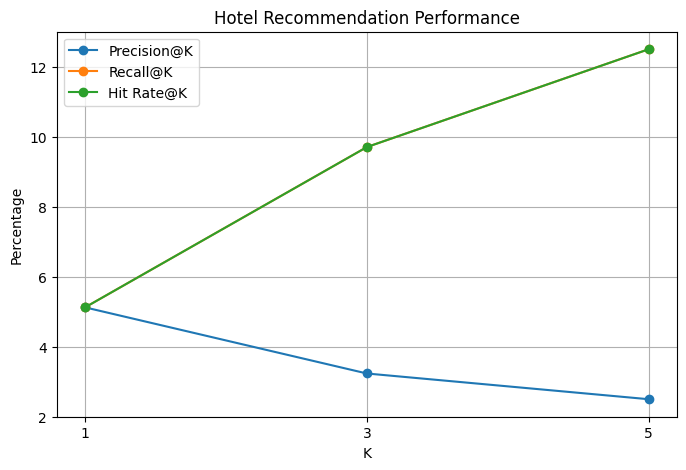

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    percentage_results["k"],
    percentage_results["Precision_at_K"],
    marker="o",
    label="Precision@K"
)

plt.plot(
    percentage_results["k"],
    percentage_results["Recall_at_K"],
    marker="o",
    label="Recall@K"
)

plt.plot(
    percentage_results["k"],
    percentage_results["Hit_Rate_at_K"],
    marker="o",
    label="Hit Rate@K"
)

plt.xlabel("K")
plt.ylabel("Percentage")
plt.title("Hotel Recommendation Performance")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

## Hit Rate@K

Hit Rate@K measures whether the actual future hotel interaction appears within the top K recommended hotels.

A hit is recorded when the held-out hotel is present in the Top-K recommendation list. Otherwise, the result is considered a miss.

Hit Rate@K is calculated as:

Hit Rate@K = Number of successful recommendations / Total number of evaluated users

In [96]:
def hit_rate_at_k(
    actual_item,
    recommended_items,
    k
):
    return int(
        actual_item in recommended_items[:k]
    )

print(
    "Hit Rate@K function created successfully."
)

Hit Rate@K function created successfully.


## Precision@K

Precision@K measures the proportion of the Top-K recommendations that correspond to the user's relevant future interaction.

Since one future hotel is held out for each user, a successful recommendation contributes 1/K to Precision@K.

In [98]:
def precision_at_k(
    actual_item,
    recommended_items,
    k
):
    recommended_top_k = recommended_items[:k]

    if actual_item in recommended_top_k:
        return 1 / k

    return 0.0

print(
    "Precision@K function created successfully."
)

Precision@K function created successfully.


## Recall@K

Recall@K measures whether the relevant future hotel was successfully retrieved within the Top-K recommendations.

Because the evaluation uses one held-out relevant hotel per user, Recall@K is either 1 when the hotel is recommended or 0 when it is not.

In [99]:
def recall_at_k(
    actual_item,
    recommended_items,
    k
):
    if actual_item in recommended_items[:k]:
        return 1.0

    return 0.0

print(
    "Recall@K function created successfully."
)

Recall@K function created successfully.


## Evaluate All Users

The recommendation system is evaluated for all eligible users using the held-out future hotel as the ground truth.

Recommendations are generated using only the user's training history. Precision@K, Recall@K, and Hit Rate@K are calculated for K = 1, 3, and 5.

In [100]:
k_values = [1, 3, 5]

results = []

for user_code in eligible_users:

    user_history = train_interactions[
        train_interactions["usercode"] == user_code
    ]

    user_test = test_interactions[
        test_interactions["usercode"] == user_code
    ]

    if user_test.empty:
        continue

    actual_hotel = user_test["name"].iloc[0]

    recommendations = recommend_for_user_from_history(
        user_history,
        top_n=max(k_values)
    )

    for k in k_values:

        results.append({
            "usercode": user_code,
            "k": k,
            "precision": precision_at_k(
                actual_hotel,
                recommendations,
                k
            ),
            "recall": recall_at_k(
                actual_hotel,
                recommendations,
                k
            ),
            "hit": hit_rate_at_k(
                actual_hotel,
                recommendations,
                k
            )
        })

evaluation_results = pd.DataFrame(results)

print(
    "Evaluation completed."
)

print(
    "Evaluation result shape:",
    evaluation_results.shape
)

display(
    evaluation_results.head(10)
)

Evaluation completed.
Evaluation result shape: (3864, 5)


,usercode,k,precision,recall,hit
0,0,1,0.0,0.0,0
1,0,3,0.0,0.0,0
2,0,5,0.0,0.0,0
3,1,1,0.0,0.0,0
4,1,3,0.0,0.0,0
5,1,5,0.2,1.0,1
6,2,1,0.0,0.0,0
7,2,3,0.0,0.0,0
8,2,5,0.0,0.0,0
9,3,1,0.0,0.0,0


## Overall Recommendation Performance

The user-level evaluation results are aggregated to obtain the overall Precision@K, Recall@K, and Hit Rate@K.

The metrics are calculated separately for K = 1, 3, and 5 to examine how recommendation performance changes as more hotels are presented to the user.

In [101]:
summary_results = (
    evaluation_results
    .groupby("k")
    .agg(
        Precision_at_K=("precision", "mean"),
        Recall_at_K=("recall", "mean"),
        Hit_Rate_at_K=("hit", "mean")
    )
    .reset_index()
)

display(
    summary_results
)

,k,Precision_at_K,Recall_at_K,Hit_Rate_at_K
0,1,0.051242,0.051242,0.051242
1,3,0.032350,0.097050,0.097050
2,5,0.025000,0.125000,0.125000


In [102]:
percentage_results = summary_results.copy()

metric_columns = [
    "Precision_at_K",
    "Recall_at_K",
    "Hit_Rate_at_K"
]

percentage_results[metric_columns] = (
    percentage_results[metric_columns] * 100
)

display(
    percentage_results.round(2)
)

,k,Precision_at_K,Recall_at_K,Hit_Rate_at_K
0,1,5.12,5.12,5.12
1,3,3.23,9.70,9.70
2,5,2.50,12.50,12.50


## Recommendation Performance Visualization

The recommendation metrics are visualized for different values of K. The visualization helps compare how Precision@K, Recall@K, and Hit Rate@K change as the number of recommended hotels increases.

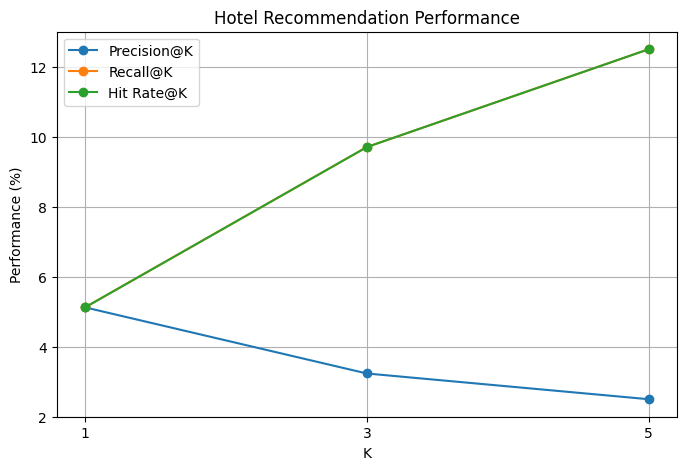

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    percentage_results["k"],
    percentage_results["Precision_at_K"],
    marker="o",
    label="Precision@K"
)

plt.plot(
    percentage_results["k"],
    percentage_results["Recall_at_K"],
    marker="o",
    label="Recall@K"
)

plt.plot(
    percentage_results["k"],
    percentage_results["Hit_Rate_at_K"],
    marker="o",
    label="Hit Rate@K"
)

plt.xlabel("K")
plt.ylabel("Performance (%)")
plt.title("Hotel Recommendation Performance")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

## Preparing the Recommendation Model for Deployment

The trained recommendation system depends on the nearest-neighbour model, hotel feature representations, hotel catalogue, and preprocessing information.

These components are packaged together so that the same recommendation logic can be reproduced later without retraining the model. The resulting package will be used by the Streamlit application for generating hotel recommendations.

In [106]:
import joblib

recommendation_package = {
    "recommendation_model": recommendation_model,
    "hotel_feature_matrix": hotel_feature_matrix,
    "hotel_catalog": hotel_catalog
}

print("Recommendation package created.")

print("\nPackage contents:")

for key, value in recommendation_package.items():
    print(f"{key}: {type(value)}")

Recommendation package created.

Package contents:
recommendation_model: <class 'sklearn.neighbors._unsupervised.NearestNeighbors'>
hotel_feature_matrix: <class 'scipy.sparse._csr.csr_matrix'>
hotel_catalog: <class 'pandas.core.frame.DataFrame'>


In [107]:
model_path = "recommendation_model.pkl"

joblib.dump(
    recommendation_package,
    model_path
)

print(
    f"Recommendation model saved to: {model_path}"
)

Recommendation model saved to: recommendation_model.pkl


In [108]:
import os

print(
    "File exists:",
    os.path.exists(model_path)
)

print(
    "File size:",
    round(
        os.path.getsize(model_path) / 1024,
        2
    ),
    "KB"
)

File exists: True
File size: 3.03 KB


## Verifying Model Loading

The saved recommendation package is loaded again to verify that all required objects were serialized correctly.

This ensures that the deployment file can be used independently of the current notebook session.

In [109]:
loaded_package = joblib.load(
    model_path
)

print("Model loaded successfully.")

print("\nLoaded components:")

for key, value in loaded_package.items():
    print(f"{key}: {type(value)}")

Model loaded successfully.

Loaded components:
recommendation_model: <class 'sklearn.neighbors._unsupervised.NearestNeighbors'>
hotel_feature_matrix: <class 'scipy.sparse._csr.csr_matrix'>
hotel_catalog: <class 'pandas.core.frame.DataFrame'>


In [110]:
loaded_model = loaded_package[
    "recommendation_model"
]

loaded_feature_matrix = loaded_package[
    "hotel_feature_matrix"
]

loaded_hotel_catalog = loaded_package[
    "hotel_catalog"
]

test_hotel = loaded_hotel_catalog[
    "name"
].iloc[0]

hotel_index = loaded_hotel_catalog.index[
    loaded_hotel_catalog["name"] == test_hotel
][0]

n_neighbors = min(
    6,
    len(loaded_hotel_catalog)
)

distances, indices = loaded_model.kneighbors(
    loaded_feature_matrix[hotel_index],
    n_neighbors=n_neighbors
)

loaded_recommendations = (
    loaded_hotel_catalog.iloc[
        indices[0][1:]
    ]
    .copy()
)

loaded_recommendations[
    "similarity_score"
] = 1 - distances[0][1:]

display(
    loaded_recommendations
)

,name,place,price,similarity_score
4,Hotel AU,Recife (PE),312.83,0.427385
1,Hotel K,Salvador (BH),263.41,0.252186
8,Hotel BP,Brasilia (DF),247.62,0.173785
2,Hotel BD,Natal (RN),242.88,0.148360
3,Hotel Z,Aracaju (SE),208.04,-0.052812


In [111]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

print("Models directory ready.")

Models directory ready.


In [112]:
import shutil

shutil.copy(
    "recommendation_model.pkl",
    "models/recommendation_model.pkl"
)

print(
    "Model copied to:",
    "models/recommendation_model.pkl"
)

Model copied to: models/recommendation_model.pkl


In [113]:
print(
    "Model exists:",
    os.path.exists(
        "models/recommendation_model.pkl"
    )
)

Model exists: True


In [114]:
print(
    "Model file:",
    os.path.exists(
        "models/recommendation_model.pkl"
    )
)

print(
    "Hotel catalogue:",
    loaded_hotel_catalog.shape
)

print(
    "Feature matrix:",
    loaded_feature_matrix.shape
)

print(
    "Number of hotels:",
    len(loaded_hotel_catalog)
)


Model file: True
Hotel catalogue: (9, 3)
Feature matrix: (9, 19)
Number of hotels: 9

Step 8 completed successfully.


## Streamlit Application Setup

The Streamlit application provides a user interface for the trained hotel recommendation system.

The application loads the serialized recommendation model and the hotel feature representation created during model development. Users can select a user ID, view the user's historical hotel interactions, and obtain personalized hotel recommendations.

In [116]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 37.5 MB/s eta 0:00:00


In [117]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.61.1


## Preparing Data for the Streamlit Application

The recommendation model package contains the trained model, hotel feature matrix, and hotel catalogue. The Streamlit application additionally requires the cleaned hotel interaction data to retrieve the historical hotels associated with a selected user.

The cleaned interaction data is therefore saved separately for use during deployment.

In [118]:
import os
import joblib

os.makedirs("streamlit_data", exist_ok=True)

hotels_clean.to_csv(
    "streamlit_data/hotels_clean.csv",
    index=False
)

print(
    "Saved:",
    "streamlit_data/hotels_clean.csv"
)

print(
    "Rows:",
    len(hotels_clean)
)

Saved: streamlit_data/hotels_clean.csv
Rows: 40552


In [119]:
print(
    "File exists:",
    os.path.exists(
        "streamlit_data/hotels_clean.csv"
    )
)

File exists: True


## Creating the Streamlit Application

The Streamlit application is implemented as a standalone Python script. It loads the saved recommendation package and historical hotel interaction data and provides an interactive interface for generating personalized recommendations.

In [120]:
app_code = r'''
import streamlit as st
import pandas as pd
import joblib


st.set_page_config(
    page_title="Voyage Analytics",
    page_icon="✈️",
    layout="wide"
)


@st.cache_resource
def load_model():

    package = joblib.load(
        "models/recommendation_model.pkl"
    )

    return package


@st.cache_data
def load_data():

    hotels = pd.read_csv(
        "streamlit_data/hotels_clean.csv"
    )

    return hotels


package = load_model()
hotels_clean = load_data()

recommendation_model = package[
    "recommendation_model"
]

hotel_feature_matrix = package[
    "hotel_feature_matrix"
]

hotel_catalog = package[
    "hotel_catalog"
]


def recommend_similar_hotels(
    hotel_name,
    top_n=5
):

    matching_indices = hotel_catalog.index[
        hotel_catalog["name"] == hotel_name
    ].tolist()

    if not matching_indices:
        return pd.DataFrame()

    hotel_index = matching_indices[0]

    total_hotels = len(hotel_catalog)

    n_neighbors = min(
        top_n + 1,
        total_hotels
    )

    distances, indices = (
        recommendation_model.kneighbors(
            hotel_feature_matrix[hotel_index],
            n_neighbors=n_neighbors
        )
    )

    result_indices = indices[0][1:]
    result_distances = distances[0][1:]

    recommendations = hotel_catalog.iloc[
        result_indices
    ].copy()

    recommendations[
        "similarity_score"
    ] = 1 - result_distances

    return recommendations.reset_index(
        drop=True
    )


def recommend_for_user(
    user_code,
    top_n=5
):

    user_history = hotels_clean[
        hotels_clean["usercode"] == user_code
    ]

    if user_history.empty:
        return pd.DataFrame()

    previous_hotels = (
        user_history["name"]
        .dropna()
        .unique()
        .tolist()
    )

    candidate_scores = {}

    for hotel_name in previous_hotels:

        if hotel_name not in set(
            hotel_catalog["name"]
        ):
            continue

        available_alternatives = max(
            0,
            len(hotel_catalog) - 1
        )

        if available_alternatives == 0:
            continue

        n_to_search = min(
            top_n * 3,
            available_alternatives
        )

        similar_hotels = recommend_similar_hotels(
            hotel_name,
            top_n=n_to_search
        )

        for _, row in similar_hotels.iterrows():

            candidate = row["name"]
            score = row["similarity_score"]

            if candidate in previous_hotels:
                continue

            candidate_scores[candidate] = (
                candidate_scores.get(
                    candidate,
                    0
                ) + score
            )

    if not candidate_scores:
        return pd.DataFrame()

    recommendations = pd.DataFrame(
        candidate_scores.items(),
        columns=[
            "name",
            "recommendation_score"
        ]
    )

    recommendations = (
        recommendations
        .sort_values(
            "recommendation_score",
            ascending=False
        )
        .head(top_n)
    )

    recommendations = recommendations.merge(
        hotel_catalog,
        on="name",
        how="left"
    )

    return recommendations.reset_index(
        drop=True
    )


st.title("✈️ Voyage Analytics")

st.subheader(
    "Personalized Hotel Recommendation System"
)

st.write(
    "Select a user to view their travel history "
    "and receive personalized hotel recommendations."
)


user_ids = sorted(
    hotels_clean["usercode"]
    .dropna()
    .unique()
    .tolist()
)

selected_user = st.selectbox(
    "Select User",
    user_ids
)


user_history = hotels_clean[
    hotels_clean["usercode"] == selected_user
].copy()


if not user_history.empty:

    st.subheader("Travel History")

    history_columns = [
        "name",
        "place",
        "price",
        "days",
        "date"
    ]

    available_columns = [
        column
        for column in history_columns
        if column in user_history.columns
    ]

    st.dataframe(
        user_history[
            available_columns
        ],
        use_container_width=True
    )


    st.subheader(
        "Recommended Hotels"
    )

    top_n = st.slider(
        "Number of recommendations",
        min_value=1,
        max_value=5,
        value=5
    )


    recommendations = recommend_for_user(
        selected_user,
        top_n=top_n
    )


    if recommendations.empty:

        st.warning(
            "No new hotels are available for "
            "recommendation for this user."
        )

    else:

        display_columns = [
            "name",
            "place",
            "price",
            "recommendation_score"
        ]

        available_display_columns = [
            column
            for column in display_columns
            if column in recommendations.columns
        ]

        st.dataframe(
            recommendations[
                available_display_columns
            ],
            use_container_width=True
        )

else:

    st.warning(
        "No historical hotel data found for "
        "the selected user."
    )
'''

with open(
    "app.py",
    "w"
) as file:
    file.write(app_code)

print("Streamlit app created successfully.")

Streamlit app created successfully.


In [121]:
import os

print(
    "app.py exists:",
    os.path.exists("app.py")
)

print(
    "File size:",
    os.path.getsize("app.py"),
    "bytes"
)

app.py exists: True
File size: 5175 bytes


In [132]:
import os
import shutil

os.makedirs(
    "streamlit",
    exist_ok=True
)

shutil.copy(
    "app.py",
    "streamlit/app.py"
)

print(
    "Streamlit application copied to:",
    "streamlit/app.py"
)

Streamlit application copied to: streamlit/app.py


In [133]:
print(
    "Streamlit app exists:",
    os.path.exists(
        "streamlit/app.py"
    )
)

Streamlit app exists: True


In [134]:
!pkill -f streamlit
!pkill -f lt

In [135]:
!ps aux | grep streamlit

root       55811  0.0  0.0   7372  3468 ?        S    11:01   0:00 /bin/bash -c ps aux | grep streamlit
root       55813  0.0  0.0   6480  2548 ?        S    11:01   0:00 grep streamlit


In [136]:
!streamlit run streamlit/app.py \
    --server.address=0.0.0.0 \
    --server.port=8501 \
    > /content/streamlit.log 2>&1 &

In [137]:
import time
time.sleep(5)

print(open("/content/streamlit.log").read())



2026-08-17 11:01:47.552 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.188.216:8501




In [138]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [139]:
!/content/cloudflared --version

cloudflared version 2026.8.2 (built 2026-08-14-12:17 UTC)


In [ ]:
! /content/cloudflared tunnel --url http://localhost:8501